## Setup and preprocessing — CCC, fresh raw load

In [2]:
import pandas as pd
import numpy as np
import os
import networkx as nx
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from dowhy import CausalModel
from econml.dml import CausalForestDML

OUTPUT_DIR = r"C:\Users\Disha Sharma\Desktop\Paper_1\RQ2\CCC"
os.makedirs(OUTPUT_DIR, exist_ok=True)

DATA_PATH = r"C:\Users\Disha Sharma\Desktop\Paper_1\ModuleWise\CCC.csv"
df = pd.read_csv(DATA_PATH)

df_sel = df.copy()

df_sel['imd_band'] = df_sel['imd_band'].replace('10-20', '10-20%')
imd_mode = df_sel['imd_band'].mode()[0]
df_sel['imd_band'] = df_sel['imd_band'].fillna(imd_mode)

final_result_map = {'Withdrawn': 0, 'Fail': 1, 'Pass': 2, 'Distinction': 3}
df_sel['final_result'] = df_sel['final_result'].map(final_result_map)

highest_education_map = {
    'No Formal quals': 0, 'Lower Than A Level': 1, 'A Level or Equivalent': 2,
    'HE Qualification': 3, 'Post Graduate Qualification': 4
}
df_sel['highest_education'] = df_sel['highest_education'].map(highest_education_map)

imd_band_map = {
    '0-10%': 0, '10-20%': 1, '20-30%': 2, '30-40%': 3, '40-50%': 4,
    '50-60%': 5, '60-70%': 6, '70-80%': 7, '80-90%': 8, '90-100%': 9
}
df_sel['imd_band'] = df_sel['imd_band'].map(imd_band_map)

age_band_map = {'0-35': 0, '35-55': 1, '55<=': 2}
df_sel['age_band'] = df_sel['age_band'].map(age_band_map)

df_sel['gender'] = df_sel['gender'].map({'F': 0, 'M': 1})
df_sel['disability'] = df_sel['disability'].map({'N': 0, 'Y': 1})

le = LabelEncoder()
df_sel['region'] = le.fit_transform(df_sel['region'])

assessment_cols = [c for c in df_sel.columns if c.startswith('ass_') and c.endswith('_score')]
for col in assessment_cols:
    df_sel[col] = df_sel[col].fillna(-1)
    try:
        df_sel[col] = pd.qcut(df_sel[col], q=4, labels=False, duplicates='drop')
    except ValueError:
        pass

click_cols = [c for c in df_sel.columns if c.startswith('clicks_')]
for col in click_cols:
    df_sel[col] = df_sel[col].fillna(0)

print(df_sel.shape)
print("Assessment columns:", assessment_cols)
print("Click columns:", click_cols)
df_sel.isna().sum().sum()

(4434, 40)
Assessment columns: ['ass_1_score', 'ass_2_score', 'ass_3_score', 'ass_4_score', 'ass_5_score', 'ass_6_score', 'ass_7_score', 'ass_8_score', 'ass_9_score']
Click columns: ['clicks_forumng', 'clicks_homepage', 'clicks_oucollaborate', 'clicks_oucontent', 'clicks_page', 'clicks_quiz', 'clicks_resource', 'clicks_subpage', 'clicks_url']


np.int64(23461)

## Click variation check, total_clicks composite, quartile binning

In [5]:
for col in click_cols:
    print(col, "nonzero:", (df_sel[col] > 0).sum(), "| unique vals:", df_sel[col].nunique())

clicks_forumng nonzero: 3295 | unique vals: 666
clicks_homepage nonzero: 3979 | unique vals: 706
clicks_oucollaborate nonzero: 1209 | unique vals: 59
clicks_oucontent nonzero: 3382 | unique vals: 612
clicks_page nonzero: 1453 | unique vals: 20
clicks_quiz nonzero: 3734 | unique vals: 1394
clicks_resource nonzero: 3848 | unique vals: 302
clicks_subpage nonzero: 3801 | unique vals: 396
clicks_url nonzero: 3574 | unique vals: 74


## total_clicks composite — sum raw clicks, quartile-bin, drop individual columns

In [8]:
df_sel['total_clicks'] = df_sel[click_cols].sum(axis=1)
df_sel['total_clicks'] = pd.qcut(df_sel['total_clicks'], q=4, labels=False, duplicates='drop')

print(df_sel['total_clicks'].nunique(), "bins")
print(df_sel['total_clicks'].value_counts().sort_index())

df_sel_combined = df_sel.drop(columns=click_cols)
print(df_sel_combined.shape)

4 bins
total_clicks
0    1113
1    1104
2    1108
3    1109
Name: count, dtype: int64
(4434, 32)


## Final modeling variable set — drop identifiers and date columns

In [11]:
date_cols = [c for c in df_sel_combined.columns if c.endswith('_date')] + ['date_registration', 'date_unregistration']
id_cols = ['code_presentation', 'id_student']

df_model = df_sel_combined.drop(columns=date_cols + id_cols)

print(df_model.shape)
df_model.columns.tolist()

(4434, 19)


['gender',
 'region',
 'highest_education',
 'imd_band',
 'age_band',
 'num_of_prev_attempts',
 'studied_credits',
 'disability',
 'final_result',
 'ass_1_score',
 'ass_2_score',
 'ass_3_score',
 'ass_4_score',
 'ass_5_score',
 'ass_6_score',
 'ass_7_score',
 'ass_8_score',
 'ass_9_score',
 'total_clicks']

## Build CCC combined DAG in networkx, derive adjustment sets

In [14]:
edges = [
    ('gender', 'studied_credits'),
    ('gender', 'ass_1_score'),
    ('region', 'highest_education'),
    ('imd_band', 'highest_education'),
    ('age_band', 'highest_education'),
    ('age_band', 'total_clicks'),
    ('num_of_prev_attempts', 'total_clicks'),
    ('ass_1_score', 'ass_2_score'),
    ('ass_1_score', 'ass_3_score'),
    ('ass_1_score', 'ass_4_score'),
    ('ass_1_score', 'ass_5_score'),
    ('ass_1_score', 'ass_6_score'),
    ('ass_1_score', 'final_result'),
    ('total_clicks', 'ass_1_score'),
    ('ass_2_score', 'ass_3_score'),
    ('ass_2_score', 'ass_4_score'),
    ('ass_2_score', 'ass_6_score'),
    ('total_clicks', 'ass_2_score'),
    ('ass_3_score', 'ass_4_score'),
    ('ass_3_score', 'ass_7_score'),
    ('ass_3_score', 'ass_8_score'),
    ('ass_3_score', 'final_result'),
    ('ass_4_score', 'ass_8_score'),
    ('ass_4_score', 'final_result'),
    ('total_clicks', 'ass_4_score'),
    ('ass_5_score', 'ass_6_score'),
    ('ass_5_score', 'ass_7_score'),
    ('ass_5_score', 'ass_9_score'),
    ('ass_5_score', 'final_result'),
    ('total_clicks', 'ass_5_score'),
    ('ass_6_score', 'ass_7_score'),
    ('ass_6_score', 'ass_8_score'),
    ('ass_6_score', 'final_result'),
    ('total_clicks', 'ass_6_score'),
    ('ass_7_score', 'ass_8_score'),
    ('ass_7_score', 'ass_9_score'),
    ('ass_7_score', 'final_result'),
    ('ass_8_score', 'ass_9_score'),
    ('ass_8_score', 'final_result'),
    ('total_clicks', 'ass_8_score'),
    ('ass_9_score', 'final_result'),
    ('total_clicks', 'final_result'),
]
undirected_pairs = [('region', 'imd_band')]

G = nx.DiGraph()
G.add_edges_from(edges)

candidates = [n for n in G.nodes() if n != 'final_result']
treatments = [n for n in candidates if nx.has_path(G, n, 'final_result')]

print("Treatments with a path to final_result:", treatments)
print("\nExcluded (no path to final_result):", [n for n in candidates if n not in treatments])

adjustment_sets = {t: list(G.predecessors(t)) for t in treatments}
for t, adj in adjustment_sets.items():
    print(t, "->", adj)

Treatments with a path to final_result: ['gender', 'ass_1_score', 'age_band', 'total_clicks', 'num_of_prev_attempts', 'ass_2_score', 'ass_3_score', 'ass_4_score', 'ass_5_score', 'ass_6_score', 'ass_7_score', 'ass_8_score', 'ass_9_score']

Excluded (no path to final_result): ['studied_credits', 'region', 'highest_education', 'imd_band']
gender -> []
ass_1_score -> ['gender', 'total_clicks']
age_band -> []
total_clicks -> ['age_band', 'num_of_prev_attempts']
num_of_prev_attempts -> []
ass_2_score -> ['ass_1_score', 'total_clicks']
ass_3_score -> ['ass_1_score', 'ass_2_score']
ass_4_score -> ['ass_1_score', 'ass_2_score', 'ass_3_score', 'total_clicks']
ass_5_score -> ['ass_1_score', 'total_clicks']
ass_6_score -> ['ass_1_score', 'ass_2_score', 'ass_5_score', 'total_clicks']
ass_7_score -> ['ass_3_score', 'ass_5_score', 'ass_6_score']
ass_8_score -> ['ass_3_score', 'ass_4_score', 'ass_6_score', 'ass_7_score', 'total_clicks']
ass_9_score -> ['ass_5_score', 'ass_7_score', 'ass_8_score']


## DoWhy ATE loop — all 13 treatments, with 95% confidence intervals

In [17]:
results = []

for treatment in treatments:
    common_causes = adjustment_sets[treatment]

    model = CausalModel(
        data=df_model,
        treatment=treatment,
        outcome='final_result',
        common_causes=common_causes if len(common_causes) > 0 else None
    )
    identified_estimand = model.identify_effect(proceed_when_unidentifiable=True)
    estimate = model.estimate_effect(
        identified_estimand,
        method_name="backdoor.linear_regression",
        confidence_intervals=True
    )

    ate = estimate.value
    ci = estimate.get_confidence_intervals()
    ci_low, ci_high = ci[0][0], ci[0][1]
    significant = not (ci_low <= 0 <= ci_high)

    results.append({
        'treatment': treatment, 'adjustment_set': common_causes,
        'ATE': ate, 'CI_lower': ci_low, 'CI_upper': ci_high, 'significant': significant
    })

    print(f"{treatment}: ATE={ate:.3f}, CI=[{ci_low:.3f}, {ci_high:.3f}], significant={significant}")

results_df = pd.DataFrame(results)
results_df

gender: ATE=-0.054, CI=[-0.128, 0.019], significant=False
ass_1_score: ATE=0.270, CI=[0.237, 0.303], significant=True
age_band: ATE=0.160, CI=[0.095, 0.226], significant=True
total_clicks: ATE=0.677, CI=[0.657, 0.698], significant=True
num_of_prev_attempts: ATE=-0.237, CI=[-0.378, -0.095], significant=True
ass_2_score: ATE=0.712, CI=[0.645, 0.778], significant=True
ass_3_score: ATE=1.075, CI=[0.989, 1.160], significant=True
ass_4_score: ATE=0.552, CI=[0.472, 0.632], significant=True
ass_5_score: ATE=0.346, CI=[0.309, 0.382], significant=True
ass_6_score: ATE=0.499, CI=[0.461, 0.537], significant=True
ass_7_score: ATE=0.533, CI=[0.470, 0.597], significant=True
ass_8_score: ATE=0.541, CI=[0.475, 0.606], significant=True
ass_9_score: ATE=0.901, CI=[0.830, 0.971], significant=True


,treatment,adjustment_set,ATE,CI_lower,CI_upper,significant
0,gender,[],-0.054482,-0.127839,0.018875,False
1,ass_1_score,"[gender, total_clicks]",0.270258,0.237458,0.303058,True
2,age_band,[],0.160308,0.094878,0.225738,True
3,total_clicks,"[age_band, num_of_prev_attempts]",0.677159,0.656560,0.697758,True
4,num_of_prev_attempts,[],-0.236594,-0.377921,-0.095268,True
5,ass_2_score,"[ass_1_score, total_clicks]",0.711540,0.644745,0.778335,True
6,ass_3_score,"[ass_1_score, ass_2_score]",1.074632,0.989257,1.160007,True
7,ass_4_score,"[ass_1_score, ass_2_score, ass_3_score, total_...",0.551871,0.471689,0.632052,True
8,ass_5_score,"[ass_1_score, total_clicks]",0.345605,0.309307,0.381904,True
9,ass_6_score,"[ass_1_score, ass_2_score, ass_5_score, total_...",0.499161,0.461100,0.537223,True


## Refutation — placebo treatment + random common cause, all 13 treatments

In [20]:
refutation_results = []

for treatment in treatments:
    common_causes = adjustment_sets[treatment]

    model = CausalModel(
        data=df_model,
        treatment=treatment,
        outcome='final_result',
        common_causes=common_causes if len(common_causes) > 0 else None
    )
    identified_estimand = model.identify_effect(proceed_when_unidentifiable=True)
    estimate = model.estimate_effect(
        identified_estimand,
        method_name="backdoor.linear_regression",
        confidence_intervals=True
    )

    original_ate = estimate.value

    placebo_refute = model.refute_estimate(
        identified_estimand, estimate,
        method_name="placebo_treatment_refuter", placebo_type="permute"
    )
    random_cause_refute = model.refute_estimate(
        identified_estimand, estimate,
        method_name="random_common_cause"
    )

    refutation_results.append({
        'treatment': treatment, 'original_ATE': original_ate,
        'placebo_new_effect': placebo_refute.new_effect,
        'random_cause_new_effect': random_cause_refute.new_effect,
        'random_cause_diff': abs(random_cause_refute.new_effect - original_ate)
    })

    print(f"{treatment}: placebo_effect={placebo_refute.new_effect:.4f}, random_cause_effect={random_cause_refute.new_effect:.4f}")

refutation_df = pd.DataFrame(refutation_results)
refutation_df

gender: placebo_effect=-0.0054, random_cause_effect=-0.0544
ass_1_score: placebo_effect=-0.0007, random_cause_effect=0.2703
age_band: placebo_effect=0.0021, random_cause_effect=0.1603
total_clicks: placebo_effect=0.0007, random_cause_effect=0.6772
num_of_prev_attempts: placebo_effect=-0.0109, random_cause_effect=-0.2366
ass_2_score: placebo_effect=-0.0014, random_cause_effect=0.7116
ass_3_score: placebo_effect=-0.0027, random_cause_effect=1.0746
ass_4_score: placebo_effect=0.0031, random_cause_effect=0.5518
ass_5_score: placebo_effect=0.0000, random_cause_effect=0.3456
ass_6_score: placebo_effect=0.0011, random_cause_effect=0.4992
ass_7_score: placebo_effect=0.0024, random_cause_effect=0.5334
ass_8_score: placebo_effect=-0.0008, random_cause_effect=0.5409
ass_9_score: placebo_effect=-0.0035, random_cause_effect=0.9006


,treatment,original_ATE,placebo_new_effect,random_cause_new_effect,random_cause_diff
0,gender,-0.054482,-0.005449,-0.054425,0.000057
1,ass_1_score,0.270258,-0.000678,0.270282,0.000024
2,age_band,0.160308,0.002090,0.160304,0.000005
3,total_clicks,0.677159,0.000652,0.677152,0.000008
4,num_of_prev_attempts,-0.236594,-0.010932,-0.236583,0.000011
5,ass_2_score,0.711540,-0.001439,0.711571,0.000031
6,ass_3_score,1.074632,-0.002732,1.074556,0.000076
7,ass_4_score,0.551871,0.003126,0.551763,0.000108
8,ass_5_score,0.345605,0.000011,0.345638,0.000033
9,ass_6_score,0.499161,0.001116,0.499157,0.000004


## EconML CausalForestDML — CATE setup, age_band vs imd_band moderators

In [23]:
cate_results = []
moderators = ['age_band', 'imd_band']

for treatment in treatments:
    adj_set = adjustment_sets[treatment]

    for moderator in moderators:
        if treatment == moderator:
            continue

        W_cols = [c for c in adj_set if c != moderator]

        X = df_model[[moderator]].values
        T = df_model[treatment].values
        Y = df_model['final_result'].values
        W = df_model[W_cols].values if len(W_cols) > 0 else None

        est = CausalForestDML(random_state=42)
        est.fit(Y, T, X=X, W=W)

        cate_values = est.effect(X)

        cate_results.append({
            'treatment': treatment, 'moderator': moderator, 'W_cols': W_cols,
            'CATE_mean': cate_values.mean(), 'CATE_min': cate_values.min(),
            'CATE_max': cate_values.max(), 'CATE_std': cate_values.std()
        })

        print(f"{treatment} | moderator={moderator}: mean={cate_values.mean():.3f}, std={cate_values.std():.3f}")

cate_df = pd.DataFrame(cate_results)
cate_df

gender | moderator=age_band: mean=-0.067, std=0.032
gender | moderator=imd_band: mean=-0.073, std=0.130
ass_1_score | moderator=age_band: mean=0.272, std=0.039
ass_1_score | moderator=imd_band: mean=0.263, std=0.066
age_band | moderator=imd_band: mean=0.145, std=0.147
total_clicks | moderator=age_band: mean=0.683, std=0.013
total_clicks | moderator=imd_band: mean=0.682, std=0.029
num_of_prev_attempts | moderator=age_band: mean=-0.216, std=0.171
num_of_prev_attempts | moderator=imd_band: mean=-0.254, std=0.275
ass_2_score | moderator=age_band: mean=0.685, std=0.028
ass_2_score | moderator=imd_band: mean=0.698, std=0.164
ass_3_score | moderator=age_band: mean=1.101, std=0.088
ass_3_score | moderator=imd_band: mean=1.093, std=0.117
ass_4_score | moderator=age_band: mean=0.612, std=0.029
ass_4_score | moderator=imd_band: mean=0.604, std=0.150
ass_5_score | moderator=age_band: mean=0.295, std=0.010
ass_5_score | moderator=imd_band: mean=0.291, std=0.068
ass_6_score | moderator=age_band: mea

,treatment,moderator,W_cols,CATE_mean,CATE_min,CATE_max,CATE_std
0,gender,age_band,[],-0.066956,-0.087246,-0.017881,0.031555
1,gender,imd_band,[],-0.072623,-0.279929,0.068592,0.129509
2,ass_1_score,age_band,"[gender, total_clicks]",0.271938,0.211574,0.296896,0.038814
3,ass_1_score,imd_band,"[gender, total_clicks]",0.263417,0.169939,0.372693,0.066158
4,age_band,imd_band,[],0.144669,-0.037799,0.420684,0.147305
5,total_clicks,age_band,[num_of_prev_attempts],0.683055,0.674735,0.703179,0.012940
6,total_clicks,imd_band,"[age_band, num_of_prev_attempts]",0.681511,0.631448,0.734017,0.029345
7,num_of_prev_attempts,age_band,[],-0.216349,-0.482802,-0.106183,0.171330
8,num_of_prev_attempts,imd_band,[],-0.253671,-0.893830,0.123754,0.274663
9,ass_2_score,age_band,"[ass_1_score, total_clicks]",0.685219,0.642045,0.703070,0.027761


## CATE point + 95% CI plots by moderator bin — looped, saved per treatment

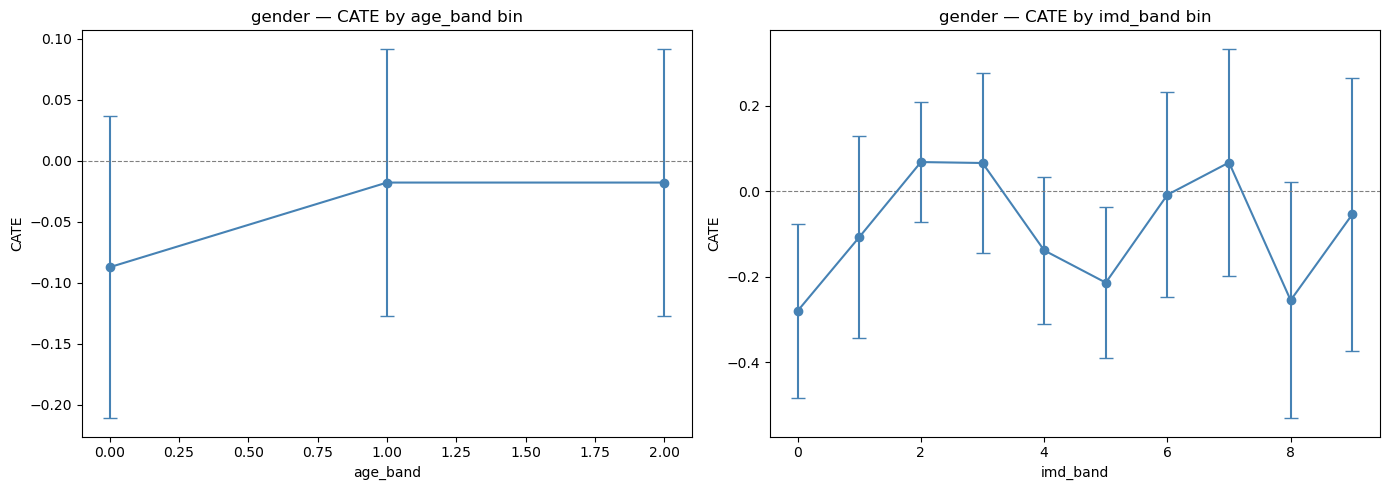

Saved: C:\Users\Disha Sharma\Desktop\Paper_1\RQ2\CCC\CCC_CATE_gender.png


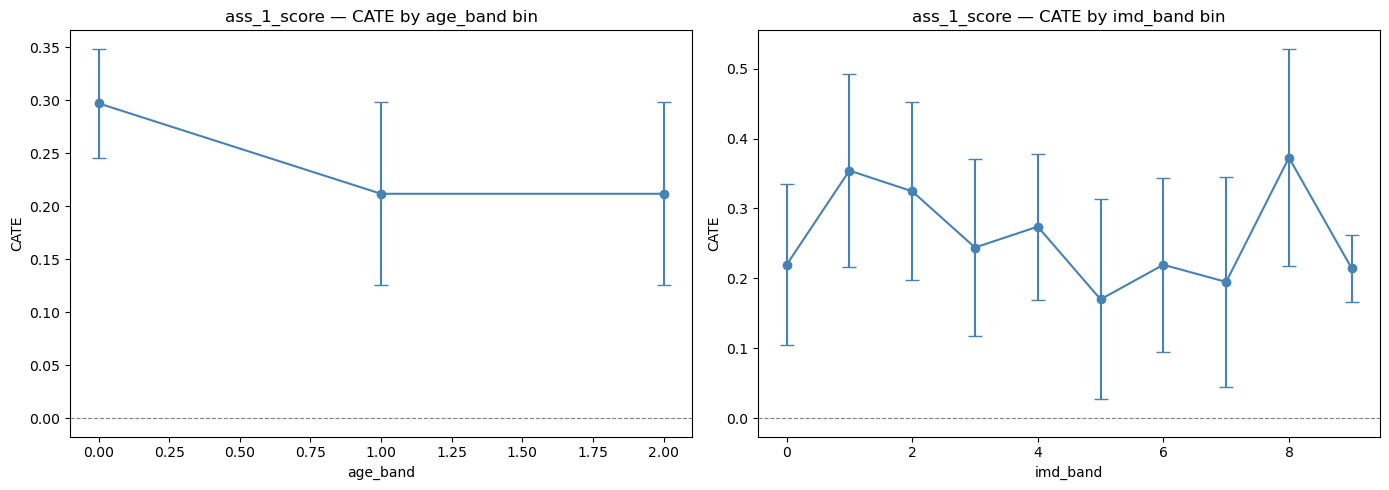

Saved: C:\Users\Disha Sharma\Desktop\Paper_1\RQ2\CCC\CCC_CATE_ass_1_score.png


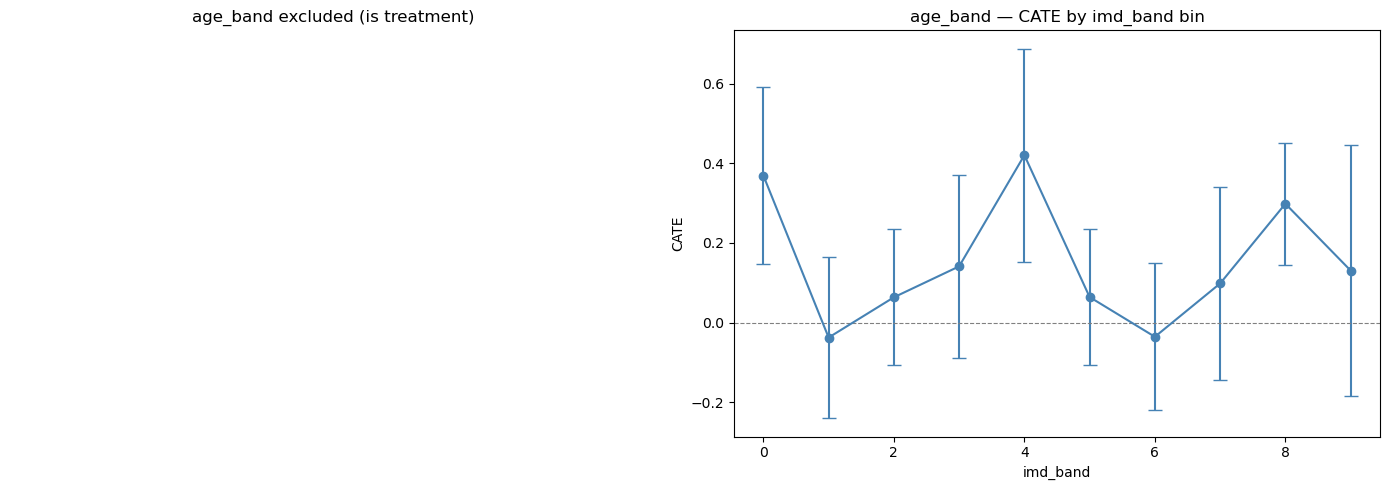

Saved: C:\Users\Disha Sharma\Desktop\Paper_1\RQ2\CCC\CCC_CATE_age_band.png


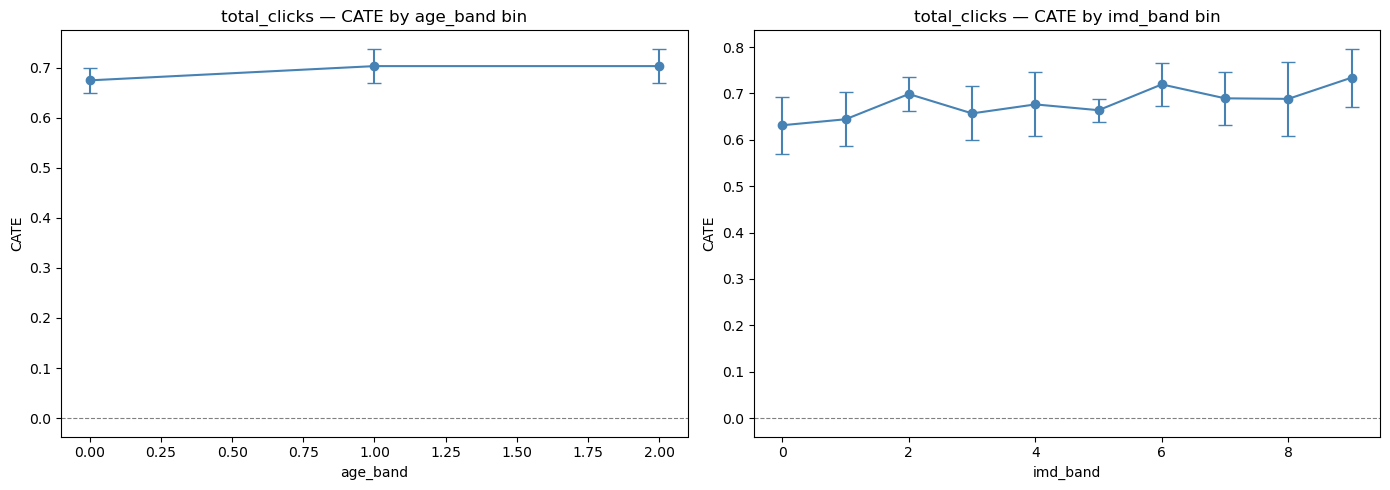

Saved: C:\Users\Disha Sharma\Desktop\Paper_1\RQ2\CCC\CCC_CATE_total_clicks.png


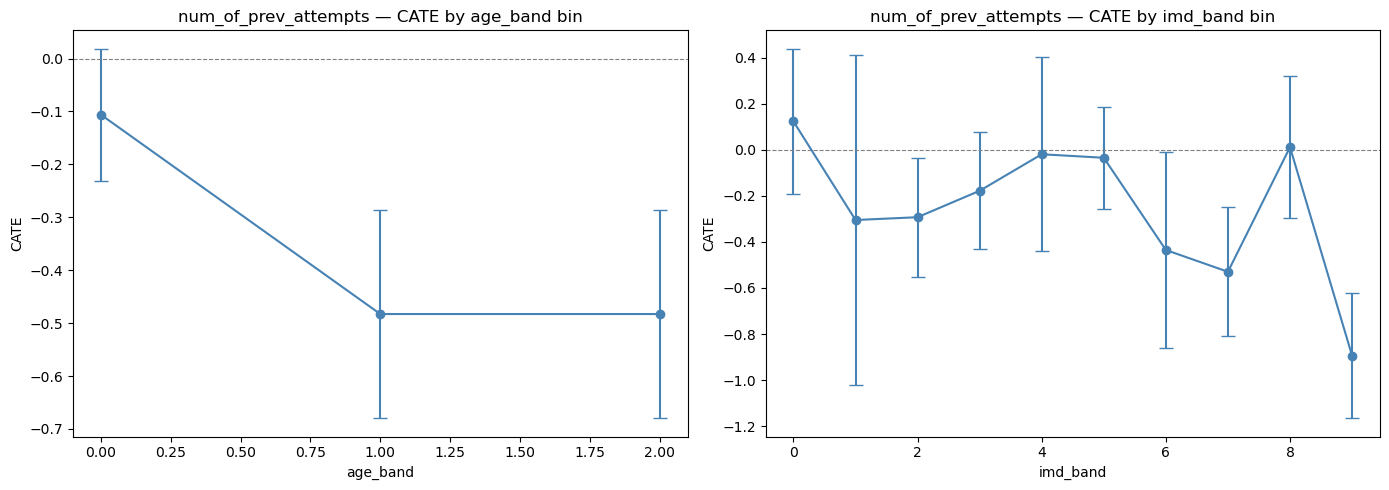

Saved: C:\Users\Disha Sharma\Desktop\Paper_1\RQ2\CCC\CCC_CATE_num_of_prev_attempts.png


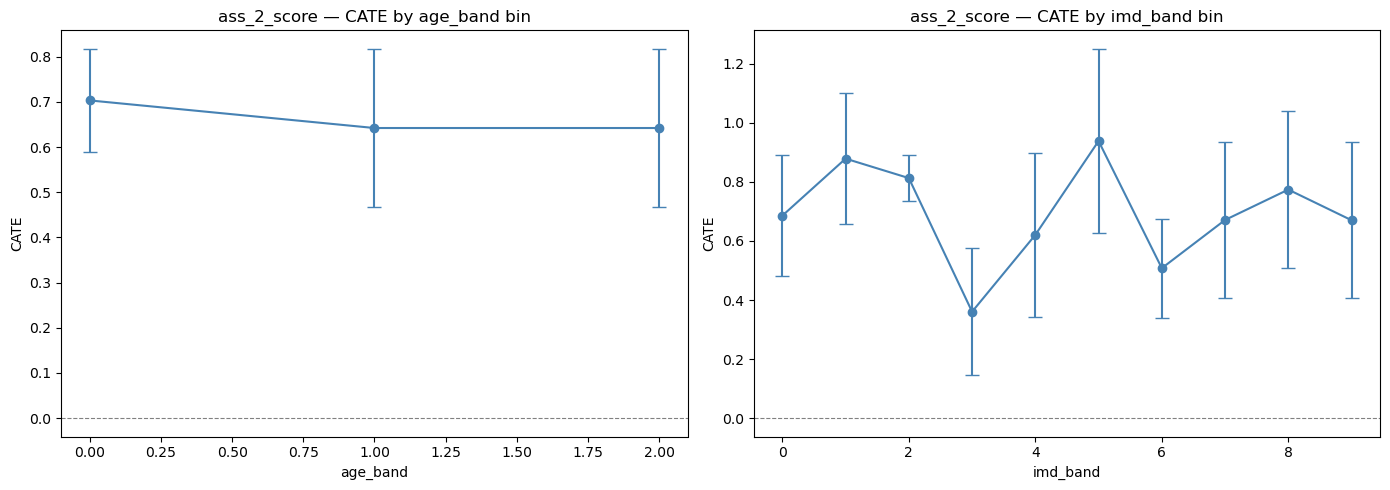

Saved: C:\Users\Disha Sharma\Desktop\Paper_1\RQ2\CCC\CCC_CATE_ass_2_score.png


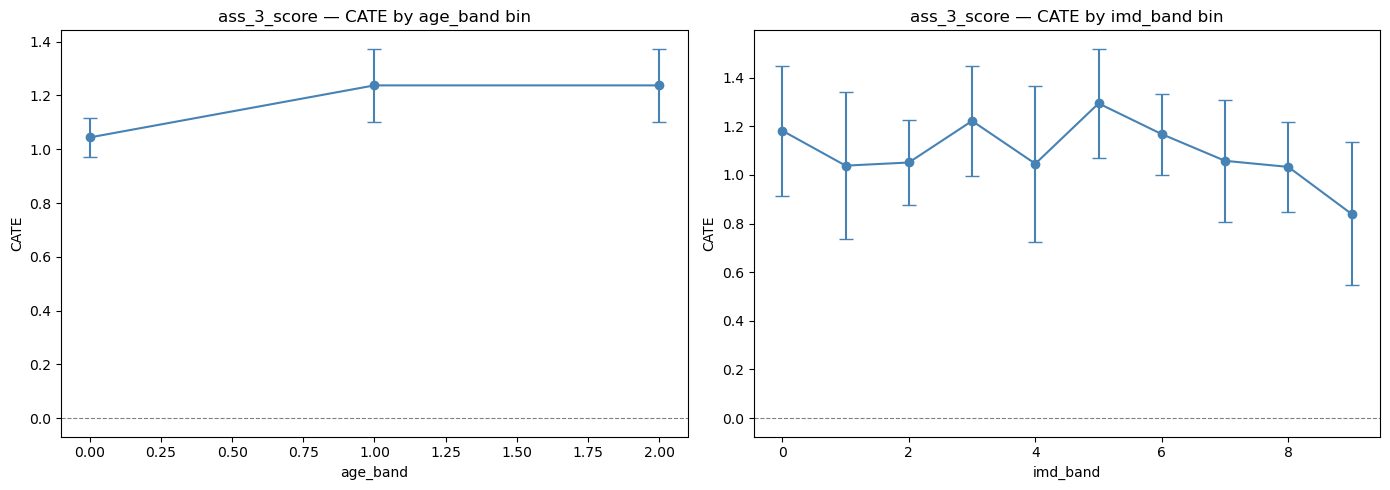

Saved: C:\Users\Disha Sharma\Desktop\Paper_1\RQ2\CCC\CCC_CATE_ass_3_score.png


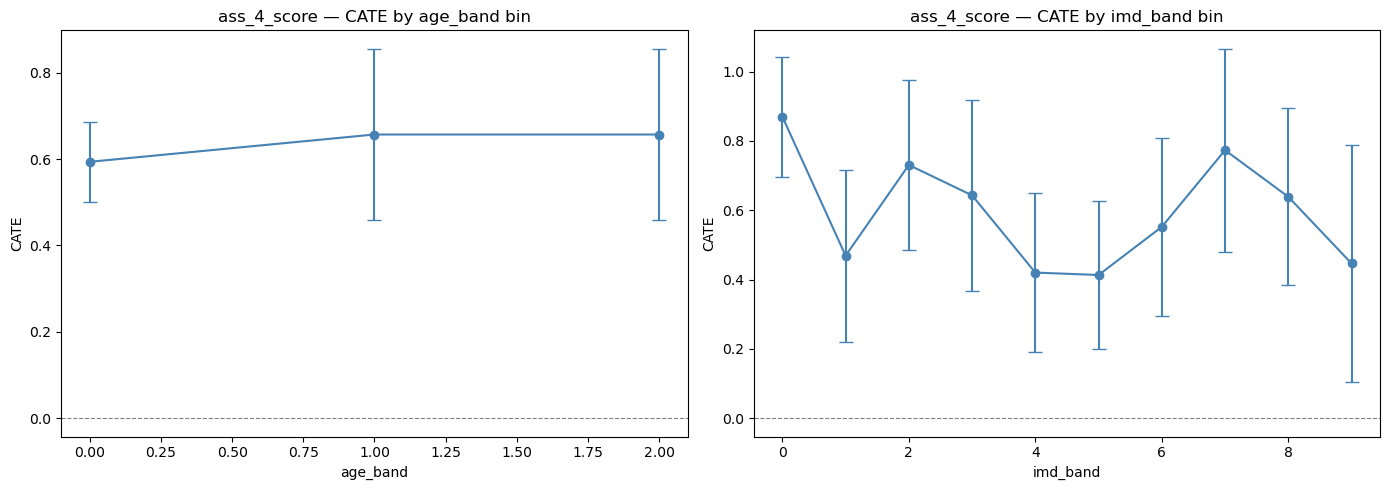

Saved: C:\Users\Disha Sharma\Desktop\Paper_1\RQ2\CCC\CCC_CATE_ass_4_score.png


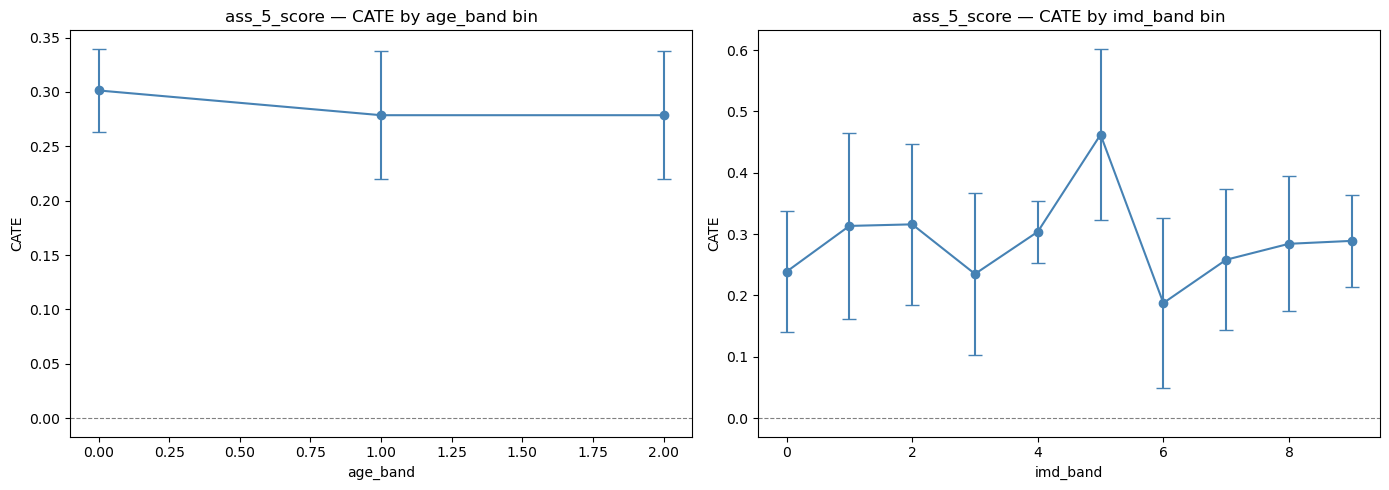

Saved: C:\Users\Disha Sharma\Desktop\Paper_1\RQ2\CCC\CCC_CATE_ass_5_score.png


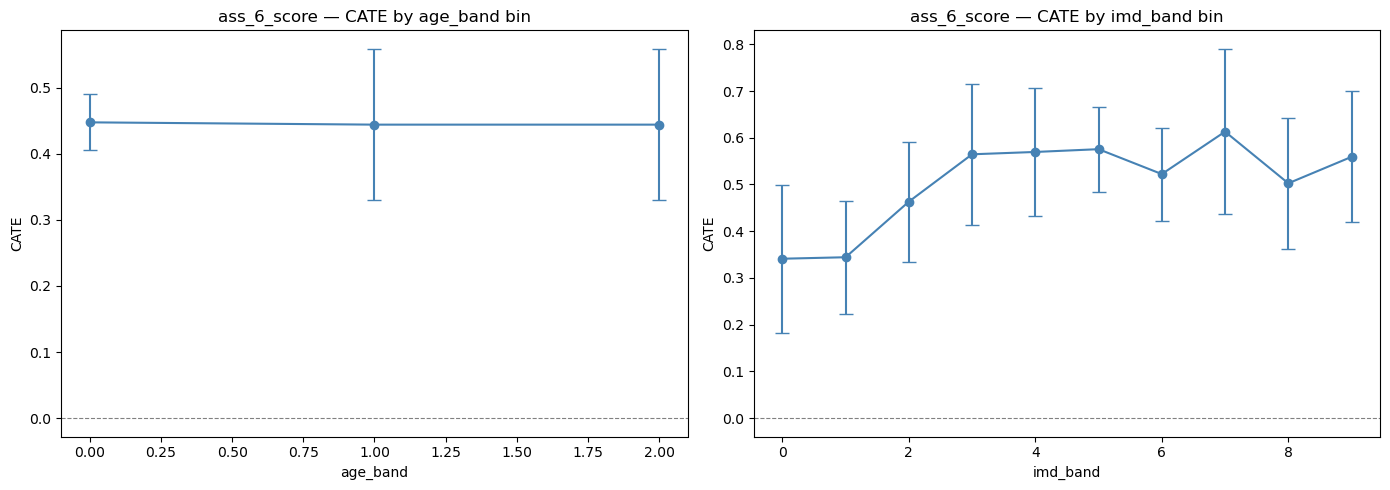

Saved: C:\Users\Disha Sharma\Desktop\Paper_1\RQ2\CCC\CCC_CATE_ass_6_score.png


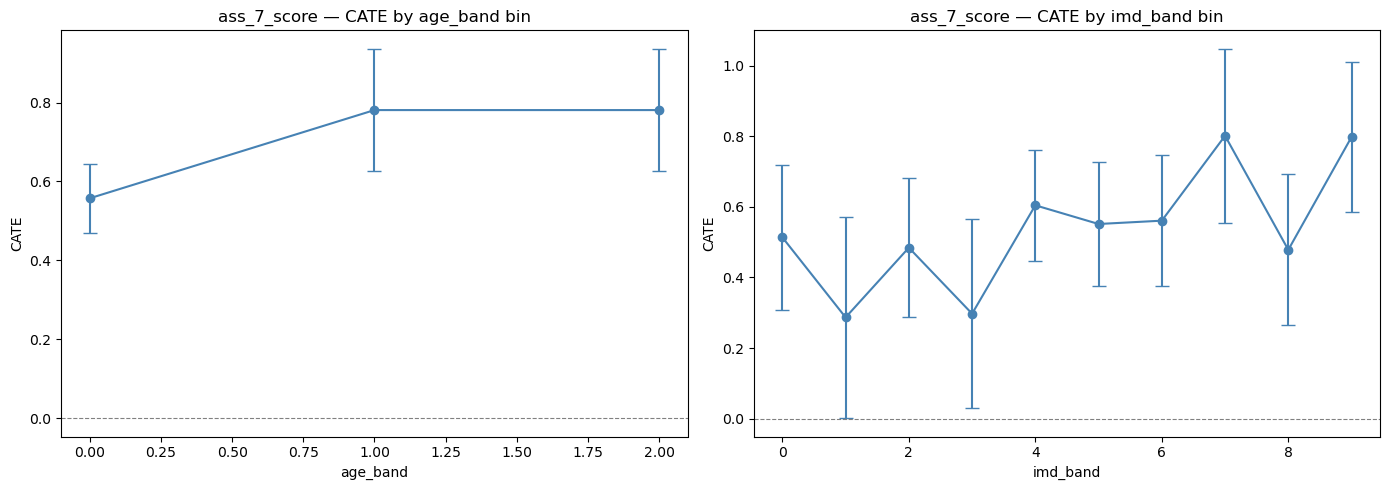

Saved: C:\Users\Disha Sharma\Desktop\Paper_1\RQ2\CCC\CCC_CATE_ass_7_score.png


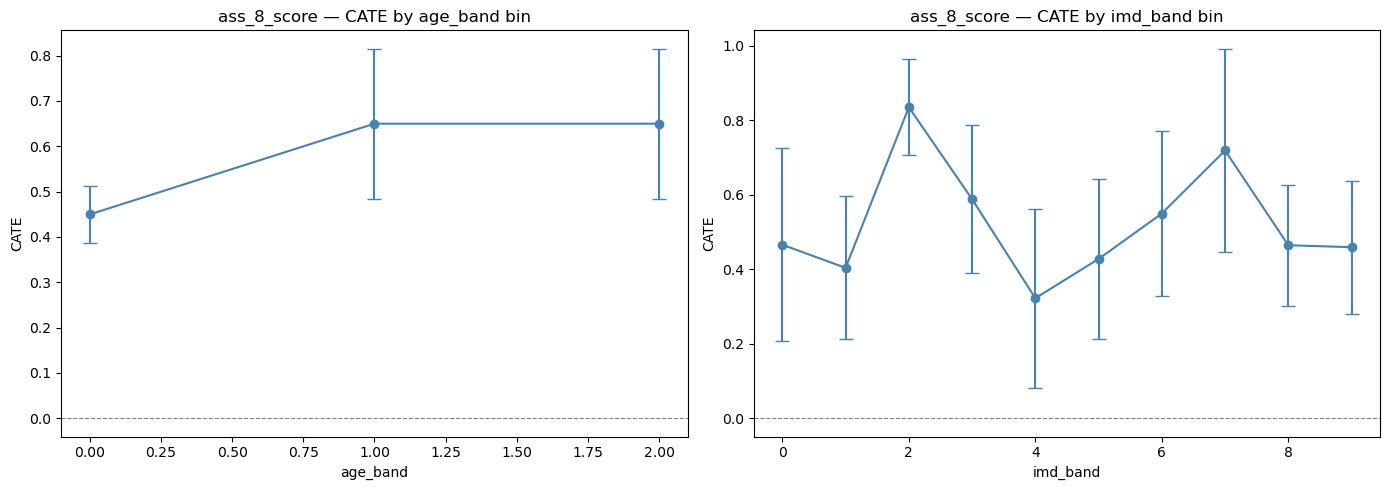

Saved: C:\Users\Disha Sharma\Desktop\Paper_1\RQ2\CCC\CCC_CATE_ass_8_score.png


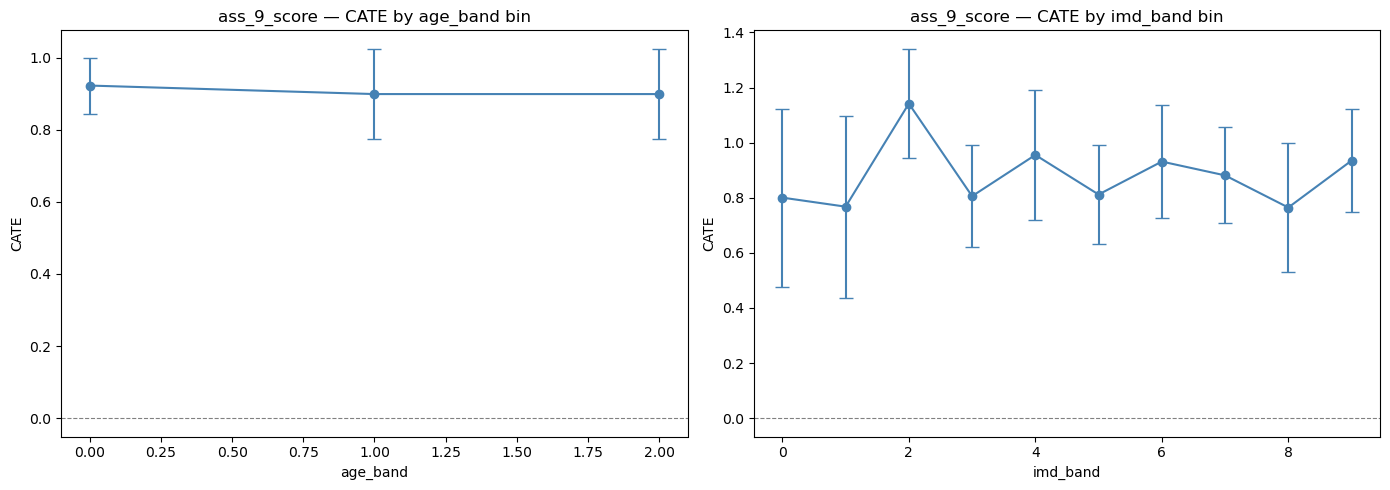

Saved: C:\Users\Disha Sharma\Desktop\Paper_1\RQ2\CCC\CCC_CATE_ass_9_score.png


In [26]:
for treatment in treatments:
    adj_set = adjustment_sets[treatment]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for ax, moderator in zip(axes, moderators):
        if treatment == moderator:
            ax.axis('off')
            ax.set_title(f"{moderator} excluded (is treatment)")
            continue

        W_cols = [c for c in adj_set if c != moderator]

        X = df_model[[moderator]].values
        T = df_model[treatment].values
        Y = df_model['final_result'].values
        W = df_model[W_cols].values if len(W_cols) > 0 else None

        est = CausalForestDML(random_state=42)
        est.fit(Y, T, X=X, W=W)

        bin_values = sorted(df_model[moderator].unique())
        X_bins = np.array(bin_values).reshape(-1, 1)

        point_estimates = est.effect(X_bins)
        lb, ub = est.effect_interval(X_bins, alpha=0.05)
        yerr = np.array([point_estimates - lb, ub - point_estimates])

        ax.errorbar(bin_values, point_estimates, yerr=yerr, fmt='o-', capsize=5, color='steelblue')
        ax.set_xlabel(moderator)
        ax.set_ylabel('CATE')
        ax.set_title(f'{treatment} — CATE by {moderator} bin')
        ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)

    plt.tight_layout()
    save_path = os.path.join(OUTPUT_DIR, f"CCC_CATE_{treatment}.png")
    plt.savefig(save_path, dpi=150)
    plt.show()
    plt.close()
    print(f"Saved: {save_path}")

## Policy tree — total_clicks only, both moderators, cost=0 (illustrative)

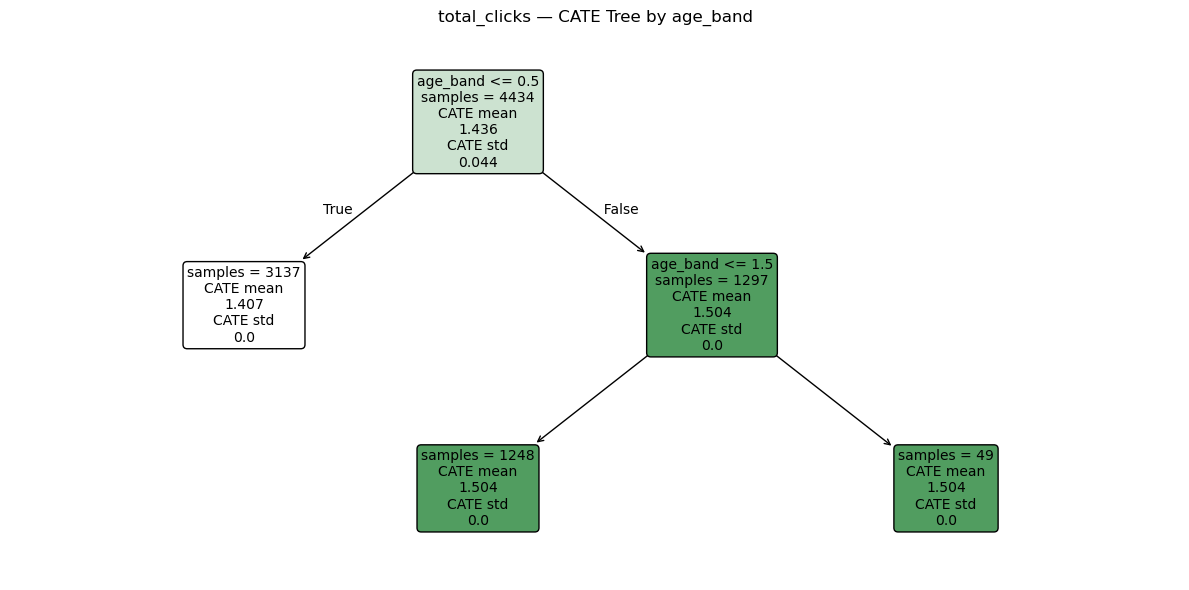

Saved: C:\Users\Disha Sharma\Desktop\Paper_1\RQ2\CCC\CCC_CATEtree_total_clicks_age_band.png


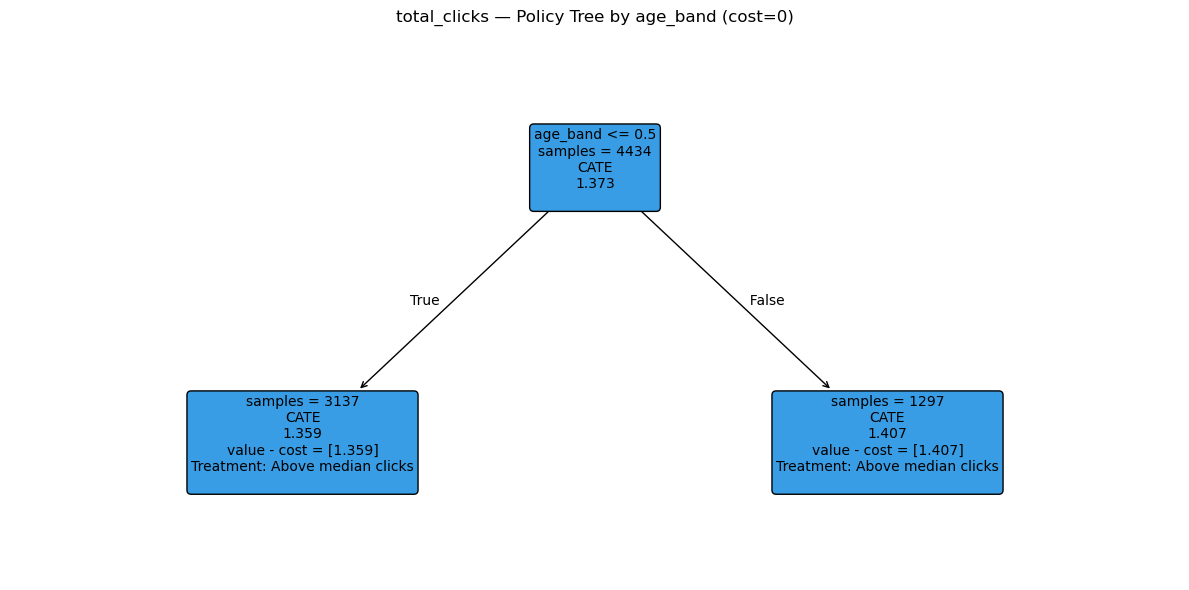

Saved: C:\Users\Disha Sharma\Desktop\Paper_1\RQ2\CCC\CCC_policy_total_clicks_age_band.png


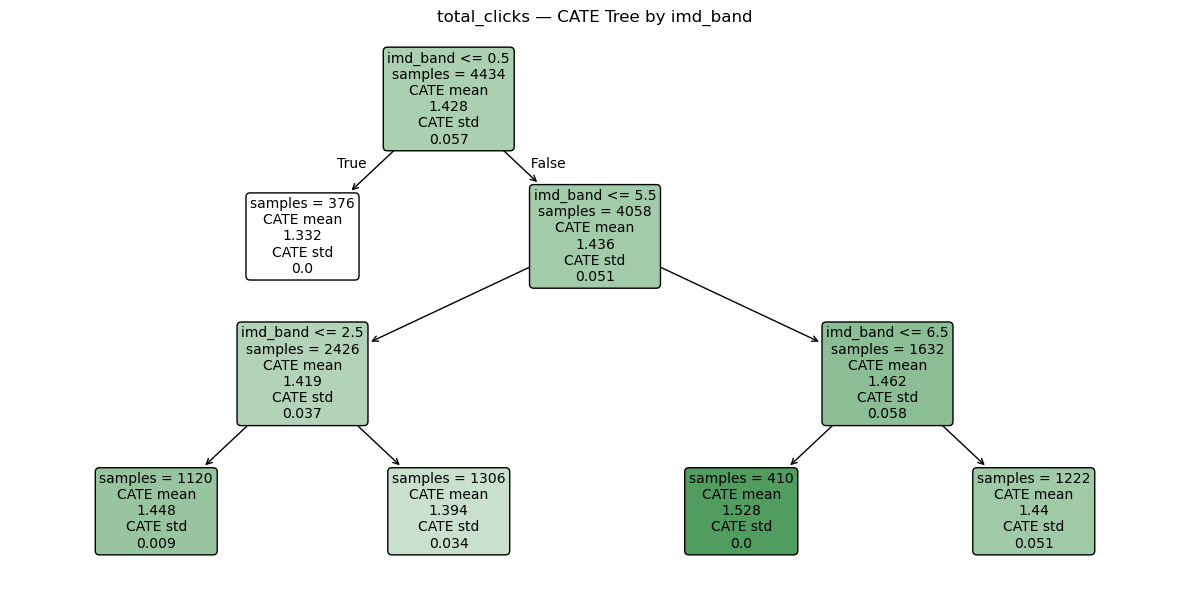

Saved: C:\Users\Disha Sharma\Desktop\Paper_1\RQ2\CCC\CCC_CATEtree_total_clicks_imd_band.png


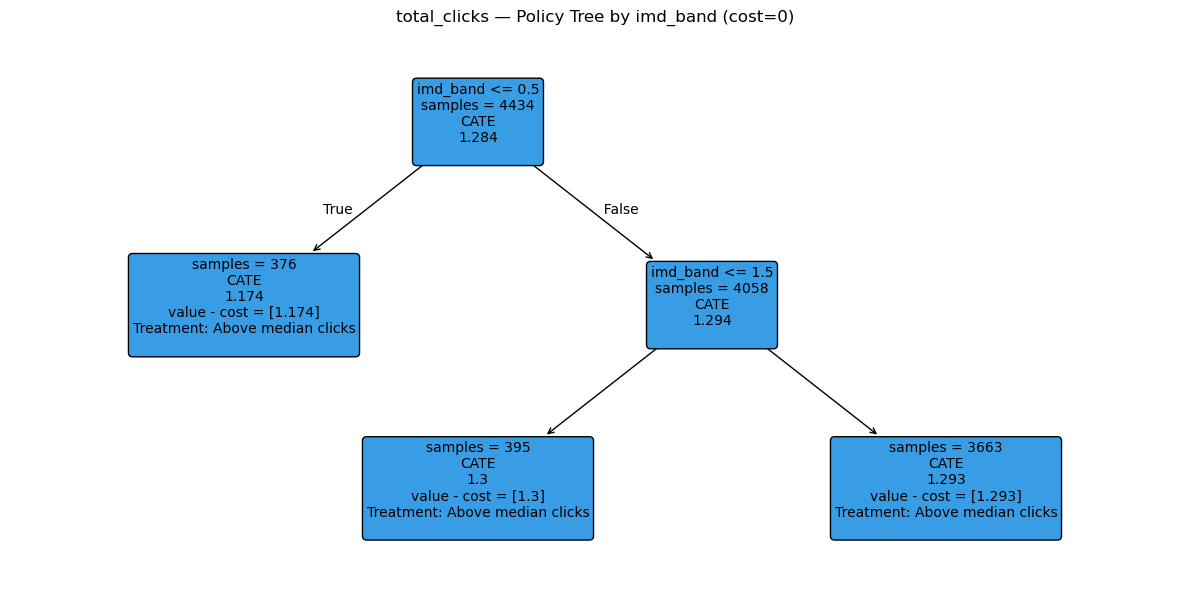

Saved: C:\Users\Disha Sharma\Desktop\Paper_1\RQ2\CCC\CCC_policy_total_clicks_imd_band.png


In [29]:
from econml.cate_interpreter import SingleTreeCateInterpreter, SingleTreePolicyInterpreter

treatment = 'total_clicks'
adj_set = adjustment_sets[treatment]

for moderator in moderators:
    W_cols = [c for c in adj_set if c != moderator]

    X = df_model[[moderator]].values
    T_binary = (df_model[treatment] >= df_model[treatment].median()).astype(int).values
    Y = df_model['final_result'].values
    W = df_model[W_cols].values if len(W_cols) > 0 else None

    est = CausalForestDML(random_state=42)
    est.fit(Y, T_binary, X=X, W=W)

    cate_interpreter = SingleTreeCateInterpreter(include_model_uncertainty=False, max_depth=3)
    cate_interpreter.interpret(est, X)

    plt.figure(figsize=(12, 6))
    cate_interpreter.plot(feature_names=[moderator], fontsize=10)
    plt.title(f'total_clicks — CATE Tree by {moderator}')
    plt.tight_layout()
    save_path = os.path.join(OUTPUT_DIR, f"CCC_CATEtree_total_clicks_{moderator}.png")
    plt.savefig(save_path, dpi=150)
    plt.show()
    plt.close()
    print(f"Saved: {save_path}")

    policy_interpreter = SingleTreePolicyInterpreter(risk_level=0.05, max_depth=3, min_samples_leaf=30)
    policy_interpreter.interpret(est, X, sample_treatment_costs=0)

    plt.figure(figsize=(12, 6))
    policy_interpreter.plot(feature_names=[moderator], treatment_names=['Below median clicks', 'Above median clicks'], fontsize=10)
    plt.title(f'total_clicks — Policy Tree by {moderator} (cost=0)')
    plt.tight_layout()
    save_path = os.path.join(OUTPUT_DIR, f"CCC_policy_total_clicks_{moderator}.png")
    plt.savefig(save_path, dpi=150)
    plt.show()
    plt.close()
    print(f"Saved: {save_path}")

## ATE heatmap

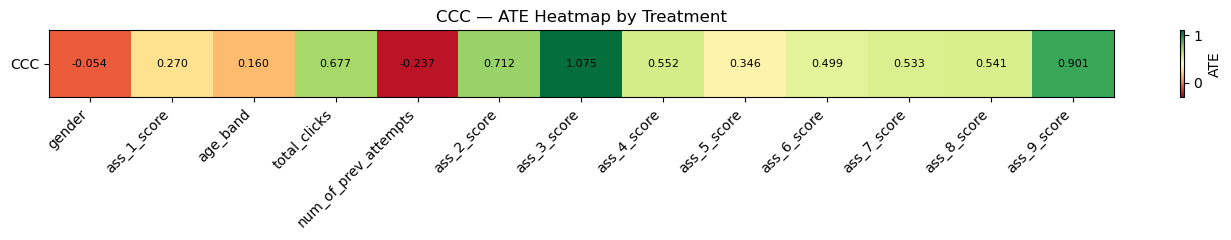

Saved: C:\Users\Disha Sharma\Desktop\Paper_1\RQ2\CCC\CCC_ATE_heatmap.png


In [32]:
heatmap_data = results_df.set_index('treatment')[['ATE']].T

plt.figure(figsize=(14, 2.5))
plt.imshow(heatmap_data.values, cmap='RdYlGn', aspect='auto', vmin=-0.3, vmax=1.1)
plt.xticks(range(len(heatmap_data.columns)), heatmap_data.columns, rotation=45, ha='right')
plt.yticks([0], ['CCC'])
plt.colorbar(label='ATE')

for i, val in enumerate(heatmap_data.values[0]):
    plt.text(i, 0, f'{val:.3f}', ha='center', va='center', fontsize=8)

plt.title('CCC — ATE Heatmap by Treatment')
plt.tight_layout()
save_path = os.path.join(OUTPUT_DIR, "CCC_ATE_heatmap.png")
plt.savefig(save_path, dpi=150)
plt.show()
plt.close()
print(f"Saved: {save_path}")

## DAG with ATE node overlay — manual fixed-position layout

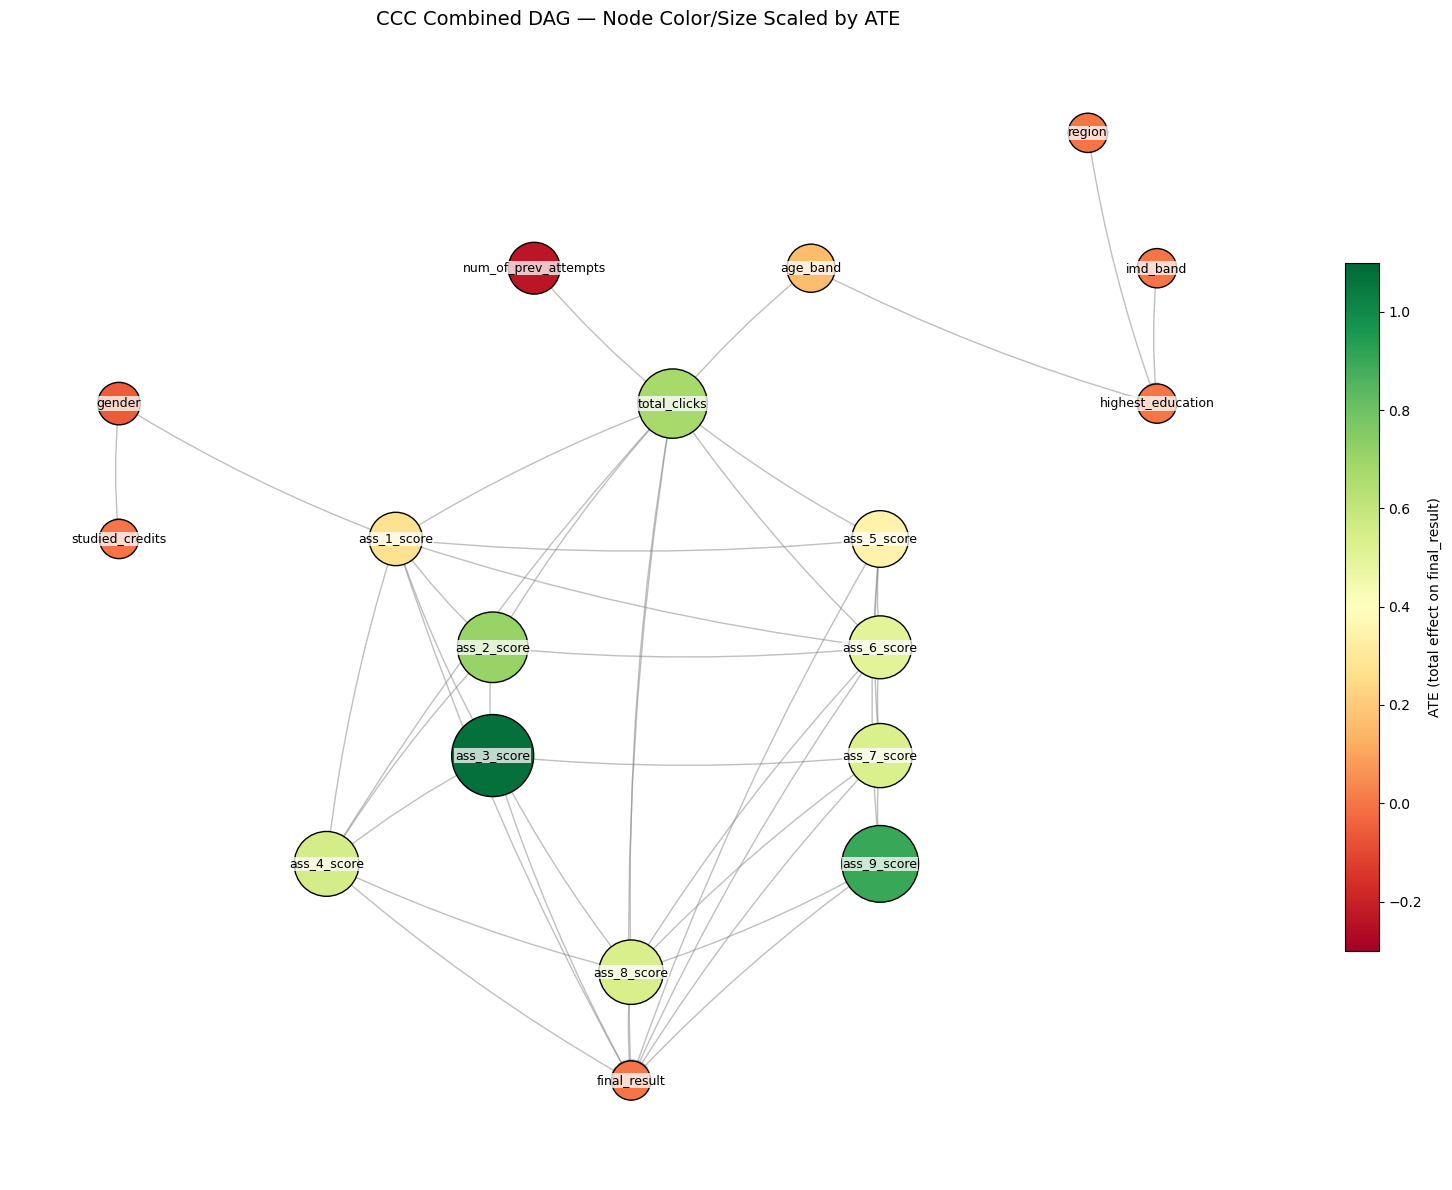

Saved: C:\Users\Disha Sharma\Desktop\Paper_1\RQ2\CCC\CCC_DAG_with_ATE.png


In [35]:
pos = {
    'region': (7.5, 9),
    'disability': (9.5, 9),
    'num_of_prev_attempts': (3.5, 7.5),
    'age_band': (5.5, 7.5),
    'imd_band': (8, 7.5),
    'total_clicks': (4.5, 6),
    'highest_education': (8, 6),
    'gender': (0.5, 6),
    'studied_credits': (0.5, 4.5),
    'ass_1_score': (2.5, 4.5),
    'ass_2_score': (3.2, 3.3),
    'ass_5_score': (6, 4.5),
    'ass_3_score': (3.2, 2.1),
    'ass_6_score': (6, 3.3),
    'ass_4_score': (2, 0.9),
    'ass_7_score': (6, 2.1),
    'ass_8_score': (4.2, -0.3),
    'ass_9_score': (6, 0.9),
    'final_result': (4.2, -1.5),
}

ate_lookup = results_df.set_index('treatment')['ATE'].to_dict()

fig, ax = plt.subplots(figsize=(16, 12))

node_colors, node_sizes = [], []
for node in G.nodes():
    ate_val = ate_lookup.get(node, 0)
    node_colors.append(ate_val)
    node_sizes.append(800 + abs(ate_val) * 2500)

missing_pos = [n for n in G.nodes() if n not in pos]
if missing_pos:
    print("WARNING — missing pos for:", missing_pos)

nx.draw_networkx_edges(G, pos, ax=ax, edge_color='gray', arrows=True, arrowsize=12, alpha=0.5, connectionstyle='arc3,rad=0.05')
nc = nx.draw_networkx_nodes(G, pos, ax=ax, node_color=node_colors, node_size=node_sizes,
                             cmap='RdYlGn', vmin=-0.3, vmax=1.1, edgecolors='black')
nx.draw_networkx_labels(G, pos, ax=ax, font_size=9,
                         bbox=dict(facecolor='white', edgecolor='none', alpha=0.75, pad=0.5))

cbar = plt.colorbar(nc, ax=ax, shrink=0.6)
cbar.set_label('ATE (total effect on final_result)')

ax.set_title('CCC Combined DAG — Node Color/Size Scaled by ATE', fontsize=14)
ax.axis('off')
plt.tight_layout()
save_path = os.path.join(OUTPUT_DIR, "CCC_DAG_with_ATE.png")
plt.savefig(save_path, dpi=150)
plt.show()
plt.close()
print(f"Saved: {save_path}")